In [183]:
import os
import sys
mvae_dir = os.path.split(os.getcwd())[0]
if mvae_dir not in sys.path:
    sys.path.append(mvae_dir)

In [184]:
%pwd
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [185]:
import torch
from torch.distributions import constraints
import lib.distributions as distr

In [186]:
#phi = torch.randn(1,2)
#w = torch.randn(4,4)
theta = torch.tensor([0,0])
A = torch.randn(4,4)
W = A @ A.T + 4 * torch.eye(4)
theta_batch = theta.repeat(3,1)
W_batch = W.repeat(3,1,1)

iscale = torch.tensor([1,1])
iscale_batch = iscale.repeat(3,1)
iloc = torch.tensor([0,0])
iloc_batch = iloc.repeat(3,1)

print(iloc.shape)

torch.Size([2])


In [187]:
mg_vm = distr.MGVonMises(loc=iloc_batch, scale=iscale_batch, precision=W_batch)
mg_vm.rsample(iloc_batch.shape)


tensor([[0.0194, 0.1648],
        [1.1819, 0.2384],
        [6.2171, 0.6541]])

phi_vals.shape torch.Size([10000, 1])
loc_batch.shape torch.Size([10000, 1])


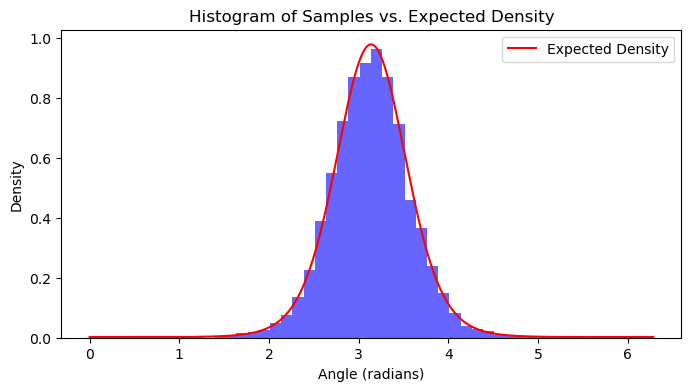

Sample Mean: 3.1296, Expected Mean: 3.1416
Sample Variance: 0.2250


In [170]:
import torch
import matplotlib.pyplot as plt

num_samples = 10000

# Define test parameters
loc = torch.tensor([torch.pi])
loc_batch = loc.repeat(num_samples,1)
scale = torch.tensor([3.0])
scale_batch = scale.repeat(num_samples,1)
A = torch.randn(2,2)
precision = 2 * torch.eye(2) + A @ A.T # Identity precision matrix
precision_batch = precision.repeat(num_samples,1,1)

# Instantiate the distribution
mg_vm = MGVonMises(loc_batch, scale_batch, precision_batch)

# Generate samples
samples = mg_vm.rsample(loc_batch.shape).squeeze().cpu().numpy()

# Plot histogram of samples
plt.figure(figsize=(8, 4))
plt.hist(samples, bins=50, density=True, alpha=0.6, color='b')

# Overlay expected von Mises density (approximate)
phi_vals = torch.linspace(0, 2*torch.pi, num_samples).unsqueeze(1)
print("phi_vals.shape",phi_vals.shape)
print("loc_batch.shape",loc_batch.shape)
expected_density = torch.exp(mg_vm._log_unnormalized_prob(phi_vals)).squeeze().cpu().numpy()
bin_width = (2 * torch.pi) / 50
expected_density /= (expected_density.sum() * bin_width)

plt.plot(phi_vals.cpu().numpy(), expected_density * num_samples / 50, 'r-', label="Expected Density")
plt.xlabel("Angle (radians)")
plt.ylabel("Density")
plt.legend()
plt.title("Histogram of Samples vs. Expected Density")
plt.show()

# Check sample mean and variance
sample_mean = samples.mean()
sample_var = samples.var()

print(f"Sample Mean: {sample_mean:.4f}, Expected Mean: {loc.item():.4f}")
print(f"Sample Variance: {sample_var:.4f}")


tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])
tensor([[False, False]])


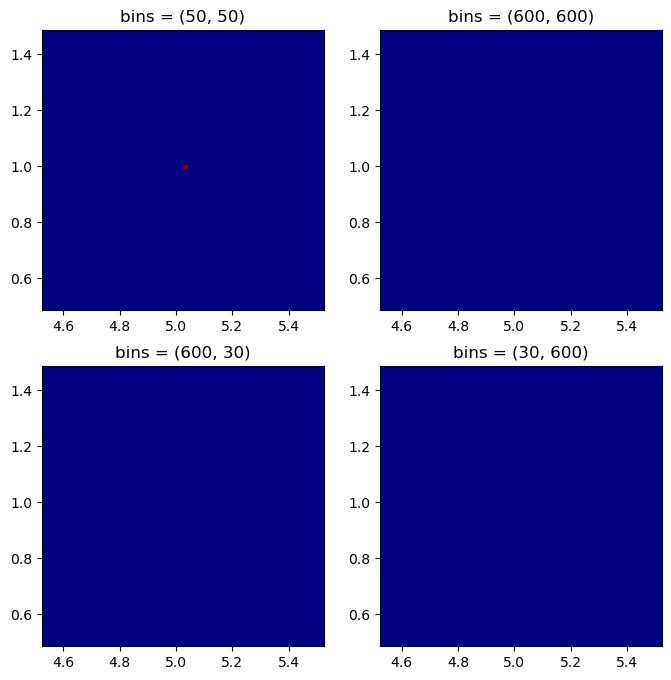

In [195]:
import torch

num_samples = 1

# Define test parameters
loc = torch.tensor([torch.pi, torch.pi/2])
loc_batch = loc.repeat(num_samples,1)
scale = torch.tensor([1.0,1.0])
scale_batch = scale.repeat(num_samples,1)
A = torch.randn(4,4)
precision = 5 * torch.eye(4) + A @ A.T
precision_batch = precision.repeat(num_samples,1,1)

# Instantiate the distribution
mg_vm = distr.MGVonMises(loc_batch, scale_batch, precision_batch)

# Generate samples
samples = mg_vm.rsample(loc_batch.shape).cpu().numpy()
samples_x, samples_y = samples[:, 0], samples[:, 1]

# Plot histogram of samples
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8,8))

# Big bins
axs[0,0].hist2d(samples_x, samples_y, bins=(50, 50), cmap=plt.cm.jet)
axs[0, 0].set_title('bins = (50, 50)')
 
# Small bins
axs[0,1].hist2d(samples_x, samples_y, bins=(600, 600), cmap=plt.cm.jet)
axs[0, 1].set_title('bins = (600, 600)')

# If you do not set the same values for X and Y, the bins won't be a square!
axs[1,0].hist2d(samples_x, samples_y, bins=(600, 30), cmap=plt.cm.jet)
axs[1, 0].set_title('bins = (600, 30)')

# If you do not set the same values for X and Y, the bins won't be a square!
axs[1,1].hist2d(samples_x, samples_y, bins=(30, 600), cmap=plt.cm.jet)
axs[1, 1].set_title('bins = (30, 600)')

plt.show()
